<font size=3;>
<p style="text-align: right;"> Lab Solution --- <b>NOT FOR DISTRIBUTION!</b> </p>
</font>

# Lab D: Data Visualization

## Setup

In [1]:
# Import some useful functions
from numpy import *
from numpy.random import *
from datascience import *
from statsmodels.formula.api import *

# Define some useful functions
def correlation(array_1, array_2):
    return corrcoef(array_1, array_2).item(1)

# Customize look of graphics
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['figure.dpi'] = 60
%matplotlib inline

# Force display of all values 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Hide some unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")
import numpy
numpy.int = numpy.int_

## Fundraising for a Political Campaign 

### Business Decision

The Director of Fundraising in California for a US presidential candidate is considering where best to focus the campaign's effort during the early period January to September of the year prior to the election.  To inform her decision, she would like insight into how fundraising has gone for other candidates in the past. 

### Data

The donor dataset here is from the US Federal Election Commission (FEC) and itemizes individual contributions from California to federal campaign committees for US presidential candidates received January 2019 to September 2019 (refer: US Federal Election Commission https://www.fec.gov/data/browse-data/?tab=bulk-data).

Retrieve the donor dataset, filter to include only transactions where amount is between \\$0 and \\$2,200 (including \\$2,200), show the number of transactions and the first few transactions.

In [69]:
data = Table.read_table('donations.csv', low_memory=False)
data = data.where('AMOUNT', are.between_or_equal_to(0, 2200))
data.num_rows
data

264119

CAND_NAME,PARTY,NAME,CITY,OCCUPATION,DATE,AMOUNT
"SANFORD, MARSHALL HON",REP,"CARATAN, PATRICK",BAKERSFIELD,blank,2019-09-08,400
"SANFORD, MARSHALL HON",REP,"PARROTT, IDA",FRESNO,RETIRED,2019-09-09,500
"SANFORD, MARSHALL HON",REP,"HUEBSCHER, FRED",HERMOSA BEACH,CONSULTANT,2019-09-08,1000
"SANFORD, MARSHALL HON",REP,"MURPHY, MIKE",LOS ANGELES,CONSULTANT,2019-09-08,1000
"DELANEY, JOHN K.",DEM,"ELVERUM, JAMIE",CARMICHAEL,SALES MANAGER,2019-07-14,25
"DELANEY, JOHN K.",DEM,"FLYNN, GREG",SAN FRANCISCO,blank,2019-03-31,1000
"DELANEY, JOHN K.",DEM,"SAUNDERS, MARSHALL L",CORONADO,RETIRED,2019-07-08,1000
"DELANEY, JOHN K.",DEM,"HOLMSTROM, RICK",WOODSIDE,blank,2019-06-20,200
"DELANEY, JOHN K.",DEM,"COWAN, GEOFFREY",LOS ANGELES,PROFESSOR,2019-04-10,20
"DELANEY, JOHN K.",DEM,"ELVERUM, JAMIE",CARMICHAEL,SALES MANAGER,2019-07-28,25


### Statistics by Party

Calculate the number of donations.  Calculate the mean \\$ donated.  Calculate the standard deviation of \\$ donated.  Calculate the total \\$ donated.

In [72]:
data.num_rows
mean(data.column('AMOUNT'))
std(data.column('AMOUNT'))
sum(data.column('AMOUNT'))

264119

101.47322986986926

221.02497604743795

26801008

Calculate the number of donations for each party.

In [73]:
agg_party_count = data.group('PARTY')
agg_party_count

PARTY,count
DEM,251145
IND,4
LIB,15
OTH,7
REP,12946
UN,1
UNK,1


Calculate the mean $ donated for each party. 

In [74]:
agg_party_mean = data.select('PARTY','AMOUNT').group('PARTY', mean)
agg_party_mean

PARTY,AMOUNT mean
DEM,101.884
IND,562.5
LIB,161.467
OTH,122.143
REP,93.2775
UN,273
UNK,25


Calculate the $ donated for each party.

In [75]:
agg_party_sum = data.select('PARTY','AMOUNT').group('PARTY', sum)
agg_party_sum

PARTY,AMOUNT sum
DEM,25587612
IND,2250
LIB,2422
OTH,855
REP,1207571
UN,273
UNK,25


Visualize the number of donations for each party as a bar chart.

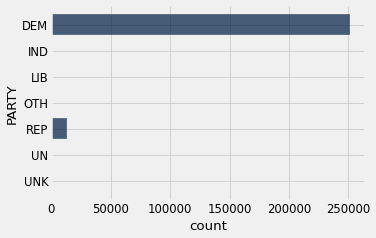

In [76]:
agg_party_count.barh('PARTY')

Visualize the mean $ donated for each party as a bar chart.

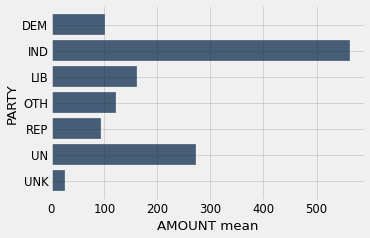

In [77]:
agg_party_mean.barh('PARTY')

Visualize the $ donated for each party as a bar chart.

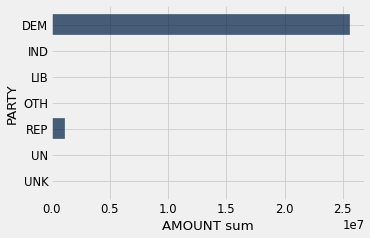

In [78]:
agg_party_sum.barh('PARTY')

### Statistics by Candidate

Visualize the number of donations for the top-10 high-count candidates as a bar chart, sorted highest to lowest.

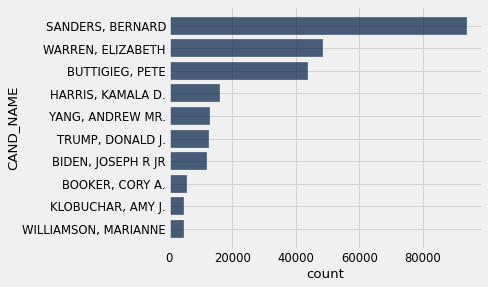

In [79]:
data.select('CAND_NAME').group('CAND_NAME').sort('count', descending=True).take(arange(10)).barh('CAND_NAME')

Visualize the mean \\$ donated for the top-10 high-mean candidates as a bar chart, sorted highest to lowest.

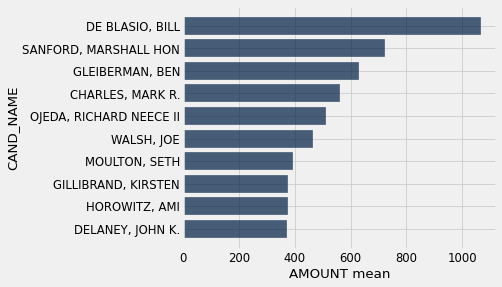

In [11]:
data.select('CAND_NAME','AMOUNT').group('CAND_NAME', mean).sort('AMOUNT mean', descending=True).take(arange(10)).barh('CAND_NAME')

Visualize the \\$ donated for the top-10 high-\\$ candidates as a bar chart, sorted highest to lowest.

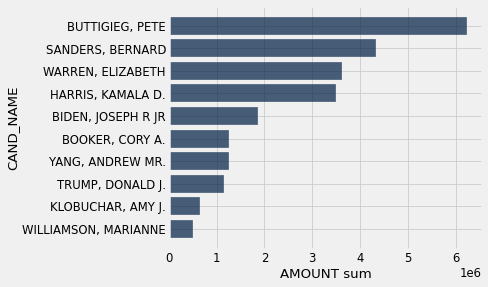

In [80]:
data.select('CAND_NAME','AMOUNT').group('CAND_NAME', sum).sort('AMOUNT sum', descending=True).take(arange(10)).barh('CAND_NAME')

### Statistics by Occupation

Calculate mean \\$ donated to Democrats for each occupation that donated to Democrats.

In [57]:
agg_dem = data.where('PARTY','DEM').select('OCCUPATION','AMOUNT').group('OCCUPATION', mean)
agg_dem = agg_dem.relabel('AMOUNT mean','DEM mean')
agg_dem

OCCUPATION,DEM mean
(NULL),178.5
.ORG DEVELOPMENT,27
122 ERSELIA TRAIL,32.5
1ST ASSISTANT DIRECTOR,16.2
2002 HASTINGS SHORE LANE,57.8333
21DEALER,10
2ND ASSISTANT CAMERA,23.875
2ND ASSISTANT CAMERAMAN,138.5
399/44 LOCAL,27
3D ANIMATION,500


Calculate mean \\$ donated to Republicans for each occupation that donated to Republicans.

In [58]:
agg_rep = data.where('PARTY','REP').select('OCCUPATION','AMOUNT').group('OCCUPATION', mean)
agg_rep = agg_rep.relabel('AMOUNT mean','REP mean')
agg_rep

OCCUPATION,REP mean
ACCOUNT EXECUTIVE,50
ACCOUNT MANAGER,31
ACCOUNTANT,49.7143
ACCOUNTING,60.2174
ACCOUNTING SPECIALIST,20
ACTING LEAD CLERK,35
ACTIVE DUTY,250
ACTOR,25
ADM ASSIST,35
ADMIN,5


Construct a table to compare mean \\$ donated to Democrats vs. mean \\$ donated to Republicans for each occupation (from among occupations that donated to both Democrats and Republicans).

In [59]:
agg = agg_dem.join('OCCUPATION', agg_rep)
agg

OCCUPATION,DEM mean,REP mean
ACCOUNT EXECUTIVE,86.6923,50
ACCOUNT MANAGER,83.0488,31
ACCOUNTANT,74.9879,49.7143
ACCOUNTING,49.551,60.2174
ACCOUNTING SPECIALIST,20,20
ACTIVE DUTY,89.5714,250
ACTOR,165.39,25
ADMIN,46.0405,5
ADMINISTRATION,69.6757,82.6923
ADMINISTRATIVE,94.2174,35


Find the 10 occupations with the highest mean \\$ donated to Democrats (from among occupations that donated to both Democrats and Republicans).  These are the top-10 Democrat donor occupations.  Use a bar chart to visualize mean \\$ donated to Democrats and mean \\$ donated to Republicans for each of the top-10 Democrat donor occupations, sorted by mean \\$ donated to Democrats.

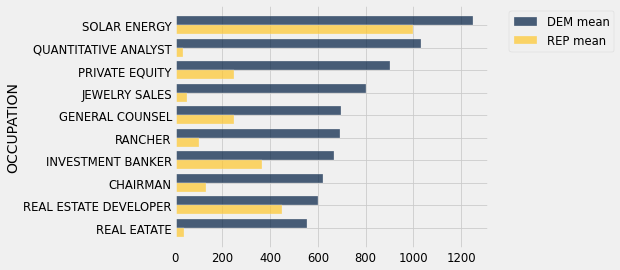

In [60]:
agg.sort('DEM mean', descending=True).take(arange(10)).barh('OCCUPATION')

Find the 10 occupations with the highest mean \\$ donated to Republicans (from among occupations that donated to both Democrats and Republicans).  These are the top-10 Republican donor occupations.  Use a bar chart to visualize mean \\$ donated to Democrats and mean \\$ donated to Republicans for each of the top-10 Republican donor occupations, sorted by mean \\$ donated to Republicans.

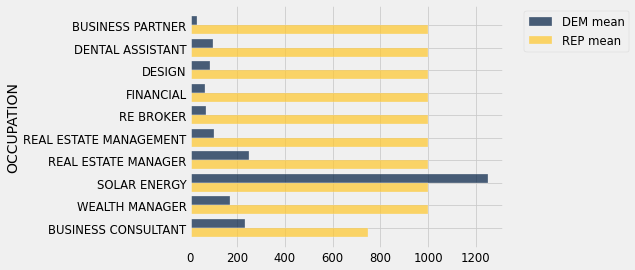

In [61]:
agg.sort('REP mean', descending=True).take(arange(10)).barh('OCCUPATION')

### Distribution of Donations

For this analysis of distribution of donations, consider donations between \\$0 and \\$100.

Construct a table to show counts of donations partitioned into 10 evenly spaced bins.  Note the bin variable indicates an amount range, the AMOUNT count variable indicates a number of donations.

In [81]:
bin_table = data.bin('AMOUNT', bins=10, range=make_array(0,100))
bin_table.show()

bin,AMOUNT count
0,41619
10,32507
20,70671
30,8949
40,2190
50,31192
60,1335
70,2071
80,698
90,32727


Visualize the counts of donations, partitioned into 10 evenly spaced bins, as a bar chart.

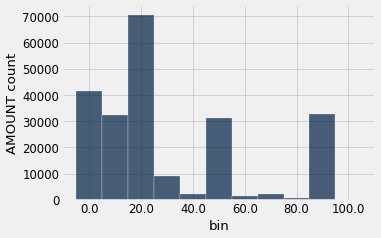

In [82]:
bin_table.bar('bin')

Visualize the counts of donations, partitioned into 10 evenly spaced bins, as a histogram.  Note that the bar chart and histogram visualizations match, except for the bar center positioning.  

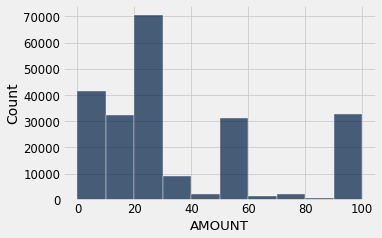

In [83]:
data.hist('AMOUNT', normed=False, bins=10, range=make_array(0,100))

Visualize the counts of donation amounts between \\$0 and \\$100, partitioned into 1000 evenly spaced bins, as a histogram.  Note that too many bins results in a non-useful histogram.

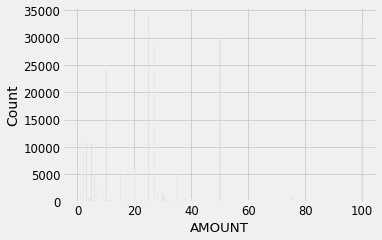

In [84]:
data.hist('AMOUNT', normed=False, bins=1000, range=make_array(0,100))

Visualize the counts of donation amounts between \\$0 and \\$100, partitioned into 3 evenly spaced bins, as a histogram.  Note that too few bins results in a non-useful histogram.

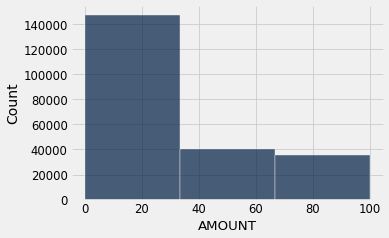

In [85]:
data.hist('AMOUNT', normed=False, bins=3, range=make_array(0,100))

Visualize the counts of donation amounts between \\$0 and \\$100 to Democrats, partitioned into 10 evenly spaced bins, as a histogram.

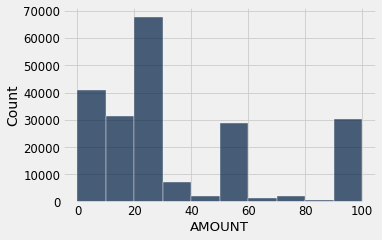

In [18]:
data.where('PARTY','DEM').hist('AMOUNT', normed=False, bins=10, range=make_array(0,100))

Visualize the counts of donation amounts between \\$0 and \\$100 to Republicans, partitioned into 10 evenly spaced bins, as a histogram.

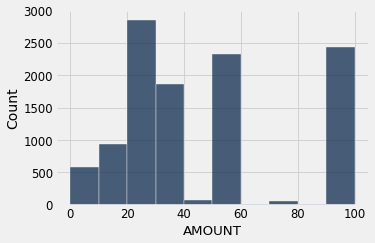

In [19]:
data.where('PARTY','REP').hist('AMOUNT', normed=False, bins=10, range=make_array(0,100))

Visualize the counts of donations, partitioned into 10 evenly spaced bins, as a histogram.  Scale the vertical axis so that area of the histogram equals one. 

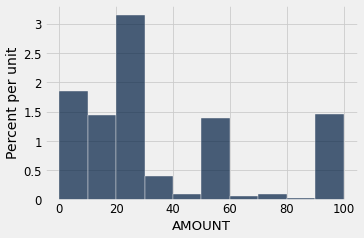

In [20]:
data.hist('AMOUNT', normed=True, bins=10, range=make_array(0,100))

Calculate the probability that a donation is between \\$0 and \\$10 given the donations between \\$0 and \\$100.  
Calculate the area of the first bar of the previous histogram.

In [21]:
x = data.where('AMOUNT', are.below(10)).num_rows
x

n = data.where('AMOUNT', are.between_or_equal_to(0, 100)).num_rows
n

p = x/n
p

41619

223959

0.18583312124094142

Calculate the height of the first bar of the previous histogram. 

In [22]:
p/10

0.018583312124094142

### Accumulation of Donations

Construct a table to show the cumulative $ donated, by date.

In [23]:
data = data.sort('DATE').with_column('CUMSUM', cumsum(data.sort('DATE').column('AMOUNT')))
data

CAND_NAME,PARTY,NAME,CITY,OCCUPATION,DATE,AMOUNT,CUMSUM
"TRUMP, DONALD J.",REP,"HASKIN, TERRY",FREEDOM,RETIRED,2019-01-01,50,50
"TRUMP, DONALD J.",REP,"JOHNSON, ADRIENNE M",LOS ALTOS,RETIRED,2019-01-01,1000,1050
"TRUMP, DONALD J.",REP,"SMITH, MIKE",SANTA CLARITA,ENTREPRENEUR,2019-01-01,250,1300
"TRUMP, DONALD J.",REP,"SCHROEDER, JILL",STOCKTON,LEGAL TECH,2019-01-01,25,1325
"TRUMP, DONALD J.",REP,"HASKIN, TERRY",FREEDOM,RETIRED,2019-01-01,50,1375
"TRUMP, DONALD J.",REP,"DAWSON, GEORGE",ALISO VIEJO,CAPTAIN,2019-01-01,50,1425
"TRUMP, DONALD J.",REP,"CELAYA, BENJAMIN",ENCINO,X-RAY TECHNOLOGIST,2019-01-01,250,1675
"TRUMP, DONALD J.",REP,"IZENBERG, ROBERT",SAN MARCOS,TRAUMA SURGEON,2019-01-01,50,1725
"TRUMP, DONALD J.",REP,"WALKOV, CINDRA",VAN NUYS,REAL EATATE,2019-01-01,35,1760
"TRUMP, DONALD J.",REP,"GRAY, MELISSA",MORAGA,RETIRED,2019-01-01,50,1810


Visualize the cumulative $ donated, by date, as a scatter plot.

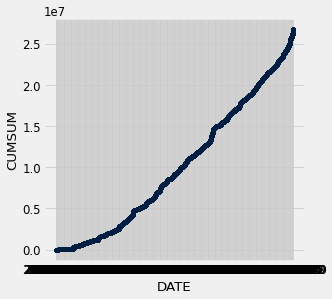

In [25]:
data.select('DATE','CUMSUM').scatter('DATE')

Visualize the cumulative $ donated, by date, as a line plot.

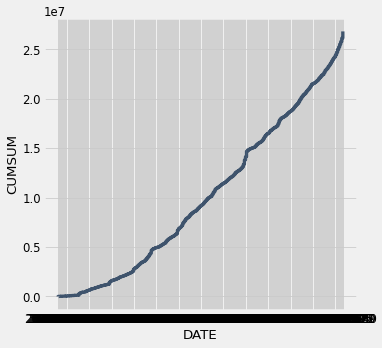

In [24]:
data.select('DATE','CUMSUM').plot('DATE')

<p style="text-align:left; font-size:10px;">
Copyright (c) Huntsinger Associates, LLC
<span style="float:right;">
Document revised September 10, 2023
</span>
</p>